# ***IBM HR Analytics Employee Attrition & Performance***

Import Libraries

In [89]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 


Load dataset

In [90]:
# Load dataset
# -----------------------------------------

df = pd.read_csv('../dataset/dataset.csv')

print(df.sample(5))

      Age Attrition     BusinessTravel  DailyRate              Department  \
59     37        No      Travel_Rarely       1115  Research & Development   
1283   28        No      Travel_Rarely       1181  Research & Development   
941    30        No      Travel_Rarely       1138  Research & Development   
90     40        No  Travel_Frequently        530  Research & Development   
416    38        No  Travel_Frequently       1490  Research & Development   

      DistanceFromHome  Education    EducationField  EmployeeCount  \
59                   1          4     Life Sciences              1   
1283                 1          3     Life Sciences              1   
941                  6          3  Technical Degree              1   
90                   1          4     Life Sciences              1   
416                  2          2     Life Sciences              1   

      EmployeeNumber  ...  RelationshipSatisfaction StandardHours  \
59                77  ...                      

In [91]:
# Shape of df
print(df.shape)

# df columns
print(df.columns)

(1470, 35)
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [92]:
# Description of the dataframe
# -------------------------------------------

print(df.describe())

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

In [93]:
# Show dataframe information 
# ---------------------------------------------

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [94]:
# Check duplicate and Null Value
# -----------------------------------------------


print('Check Duplicate :\n',df.duplicated().sum()) # check duplicate

print('-'*200)

print('Check Null Values: \n', df.isnull().sum()) # check Null values

Check Duplicate :
 0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Check Null Values: 
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
Relatio

# Feature Selection 

In [95]:
# print(df.sample(3))

Identify single value columns

In [96]:
# Identify Single value Columns

single_val_col = []
for col in df.columns:
    if(len(df[col].unique()) == 1): 
        single_val_col.append(col)
print(single_val_col)




['EmployeeCount', 'Over18', 'StandardHours']


In [97]:
# Feature Selection 
# -------------------------------------------------

# drop a single value columns
df = df.drop(columns = single_val_col)


print(len(df.columns))


# Also delete employee number columns(Not required to train a model)
df = df.drop(columns = ['EmployeeNumber', 'TrainingTimesLastYear'])
print(df)


32
      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EnvironmentSatisfactio

In [98]:
print(df.columns)


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [99]:
# df['Attrition'] = df['Attrition'].map({
#     'Yes': 1,
#     'No': 0
# })

In [100]:

# print(df.columns)
# numerica_col = df.select_dtypes(include=['int64']).columns
# print('Numeric Column: ',numerica_col)

# corr = df[numerica_col].corr()['Attrition'].sort_values()
# print(corr)

**Correlation Matrix for Numerical Columns**

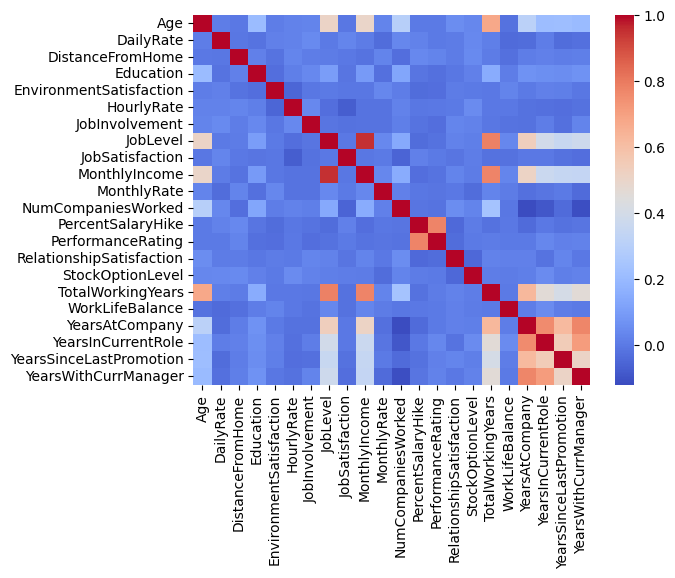

In [101]:
# Correlation Matrix
# -------------------------------------------


corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=False,
            cmap='coolwarm')
plt.show()

**Encoding Categorical to numerical column**

In [102]:
# ======================================================
# Categorical Feature Encoding
# ======================================================

# Binary Categorical Feature (Label Encoding)
# ------------------------------------------------------
# 1. Gender      : Female, Male
# 2. Attrition   : Yes, No (Target Variable)
# 3. OverTime    : Yes, No

binary_columns = ['Attrition', 'Gender', 'OverTime']


# Nominal Categorical Feature (One hot Encoding)
# ------------------------------------------------------
# 1. BusinessTravel     : ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
# 2. Department         : ['Sales' 'Research & Development' 'Human Resources']
# 3. EducationField     : ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree' 'Human Resources']
# 4. JobRole            : ['Sales Executive' 'Research Scientist' 'Laboratory Technician' 'Manufacturing Director' 'Healthcare Representative' 'Manager''Sales Representative' 'Research Director' 'Human Resources']
# 5. MaritalStatus      : ['Single' 'Married' 'Divorced']


Ont_hot_Encoding_columns = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'MaritalStatus',
    'JobRole'
]


In [103]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Binary Encoding  (Label Encoding)

for col in binary_columns:
    df[col] = le.fit_transform(df[col])

print(df.sample(4))

     Age  Attrition BusinessTravel  DailyRate              Department  \
396   43          0  Travel_Rarely       1473  Research & Development   
460   26          0  Travel_Rarely        775                   Sales   
194   45          0     Non-Travel       1195  Research & Development   
602   30          0  Travel_Rarely        946  Research & Development   

     DistanceFromHome  Education EducationField  EnvironmentSatisfaction  \
396                 8          4          Other                        3   
460                29          2        Medical                        1   
194                 2          2        Medical                        1   
602                 2          3        Medical                        3   

     Gender  ...  PercentSalaryHike  PerformanceRating  \
396       0  ...                 14                  3   
460       1  ...                 12                  3   
194       1  ...                 23                  4   
602       0  ...     

In [104]:
# One hot encoding

df = pd.get_dummies(
    df, 
    columns=Ont_hot_Encoding_columns,
    drop_first=True,
    dtype=int
)

print(df.sample(5))

      Age  Attrition  DailyRate  DistanceFromHome  Education  \
45     41          1       1360                12          3   
766    50          0       1464                 2          4   
1003   25          0        949                 1          3   
230    52          0       1323                 2          3   
10     35          0        809                16          3   

      EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel  \
45                          2       0          49               3         5   
766                         2       1          62               3         5   
1003                        1       1          81               3         1   
230                         3       0          89               2         1   
10                          1       1          84               4         1   

      ...  MaritalStatus_Married  MaritalStatus_Single  \
45    ...                      1                     0   
766   ...               

In [105]:
print(df.columns)

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'MaritalStatus_Married',
       'MaritalStatus_Single', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_R

In [106]:
print(min(df['DailyRate']))
print(max(df['DailyRate']))

102
1499


**Split the dataset**

In [107]:
# Splitting a dataset
from sklearn.model_selection import train_test_split
# print(df.head(2))
X = df.drop(columns=['Attrition'])
Y = df['Attrition']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [108]:
# print(X_train.sample(5))

print(type(X_train))
print('-'*200)
print(X_test)

<class 'pandas.core.frame.DataFrame'>
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
      Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
1041   28        866                 5          3                        4   
184    53       1084                13          2                        4   
1222   24        240                22          1                        4   
67     45       1339                 7          3                        2   
220    36       1396                 5          2                        4   
...   ...        ...               ...        ...                      ...   
567    34        304                 2          3                        4   
560    34        167                 8          5                        2   
945    50       1322                28          3          

# **Feature Scaling**

In [109]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)

[[-1.38855944 -1.10813858  1.44039645 ... -0.50901929 -0.52486957
  -0.26099788]
 [-2.04073779 -1.2634814  -0.52269928 ...  1.96456207 -0.52486957
  -0.26099788]
 [-0.84507748  1.10364737  1.31770296 ... -0.50901929  1.90523522
  -0.26099788]
 ...
 [-1.60595222  1.1258392  -0.76808624 ...  1.96456207 -0.52486957
  -0.26099788]
 [-0.84507748  1.42666182  0.45884859 ... -0.50901929 -0.52486957
  -0.26099788]
 [ 1.43754676 -1.32019386 -0.03192534 ... -0.50901929 -0.52486957
  -0.26099788]]


In [110]:
# Model where Feature scaling require
# -------------------------------------------------------
# SVM, 
# KNN, 
# K Mean Clustering, 
# Deep Learning 
# -------------------------------------------------------

# ======================================================= 


from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier



svm = SVC()
knn = KNeighborsClassifier()

# Train SVM 
svm.fit(X_train_scaled, Y_train)
y_pred_svm = svm.predict(X_test_scaled)

# Train KNN
knn.fit(X_train_scaled, Y_train)
y_pred_knn = knn.predict(X_test_scaled)



In [111]:
# Model where No Feature scaling require
# -------------------------------------------------------
# Logistic Regression
# Random Forest Classifier  
# Decision Tree
# -------------------------------------------------------

# ======================================================= 

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier



lr  = LogisticRegression()
rf = RandomForestClassifier(
    n_estimators=200,
)
dt = DecisionTreeClassifier()

# Linear Regressor train
lr.fit(X_train_scaled, Y_train)
y_pred_lr = lr.predict(X_test_scaled)

# decision tree train
dt.fit(X_train, Y_train)
y_pred_dt = dt.predict(X_test)

# random forest classifier train
rf.fit(X_train, Y_train)
y_pred_rf = rf.predict(X_test)



In [112]:
# Calculate the Metrics

from sklearn.metrics import accuracy_score, f1_score, precision_score

print(f'SVM Accuracy: {accuracy_score(Y_test, y_pred_svm)}')
print(f'KNN Accuracy: {accuracy_score(Y_test, y_pred_knn)}')
print(f'Logistic Regression Accuracy: {accuracy_score(Y_test, y_pred_lr)}')
print(f'Decision Tree Accuracy: {accuracy_score(Y_test, y_pred_dt)}')
print(f'Random Forest Accuracy: {accuracy_score(Y_test, y_pred_rf)}')

print('-'*200)

print(f'SVM precision: {precision_score(Y_test, y_pred_svm)}')
print(f'KNN precision: {precision_score(Y_test, y_pred_knn)}')
print(f'Logistic Regression precision: {precision_score(Y_test, y_pred_lr)}')
print(f'Decision Tree precision: {precision_score(Y_test, y_pred_dt)}')
print(f'Random Forest precision: {precision_score(Y_test, y_pred_rf)}')

print('-'*200)

print(f'SVM F1 Score: {f1_score(Y_test, y_pred_svm)}')
print(f'KNN F1 Score: {f1_score(Y_test, y_pred_knn)}')
print(f'Logistic Regression F1 Score: {f1_score(Y_test, y_pred_lr)}')
print(f'Decision Tree F1 Score: {f1_score(Y_test, y_pred_dt)}')
print(f'Random Forest F1 Score: {f1_score(Y_test, y_pred_rf)}')

SVM Accuracy: 0.8979591836734694
KNN Accuracy: 0.8775510204081632
Logistic Regression Accuracy: 0.891156462585034
Decision Tree Accuracy: 0.7755102040816326
Random Forest Accuracy: 0.8741496598639455
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
SVM precision: 0.9090909090909091
KNN precision: 0.6
Logistic Regression precision: 0.6206896551724138
Decision Tree precision: 0.18604651162790697
Random Forest precision: 0.625
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
SVM F1 Score: 0.4
KNN F1 Score: 0.3333333333333333
Logistic Regression F1 Score: 0.5294117647058824
Decision Tree F1 Score: 0.1951219512195122
Random Forest F1 Score: 0.2127659574468085
